In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [56]:
!pip install -r requirements.txt

  Using cached streamlit-1.46.1-py3-none-any.whl.metadata (9.0 kB)
  Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
Using cached streamlit-1.46.1-py3-none-any.whl (10.1 MB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached gitpython-3.1.50-py3-none-any.whl (212 kB)
Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
Using cached pydeck-0.9.2-py2.py3-none-any.whl (11.3 MB)
Using cached gitdb-4.0.12-py3-none-any.whl (62 kB)
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.3
    Uninstalling ml_dtypes-0.5.3:
      Successfully uninstalled ml_dtypes-0.5.3
  Attempting uninstall: blinker

In [57]:
import os
print(os.listdir("/content"))

['.config', 'training_log.csv', 'best_model.keras', 'BUSI_Classification', 'requirements.txt', 'BUSI_Dataset', 'archive (1).zip', '.ipynb_checkpoints', 'sample_data']


In [58]:
print(os.listdir("/content/BUSI_Dataset"))

['Dataset_BUSI_with_GT']


In [59]:
import os
print(os.listdir("/content"))

['.config', 'training_log.csv', 'best_model.keras', 'BUSI_Classification', 'requirements.txt', 'BUSI_Dataset', 'archive (1).zip', '.ipynb_checkpoints', 'sample_data']


In [60]:
!unzip -q "/content/archive (1).zip" -d "/content/BUSI_Dataset"

replace /content/BUSI_Dataset/Dataset_BUSI_with_GT/benign/benign (1).png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [61]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.17.1
Keras: 3.5.0


In [ ]:
import os
print(os.listdir("/content/BUSI_Dataset"))

['Dataset_BUSI_with_GT']


In [62]:
print(class_names)

for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)
    print(images.dtype)
    print(tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy())

['benign', 'malignant', 'normal']
(32, 224, 224, 3)
(32,)
<dtype: 'float32'>
0.0 255.0


In [65]:
import os

print("="*70)
print("Dataset Structure")
print("="*70)

for root,dirs,files in os.walk("/content/BUSI_Dataset"):

    print(root)

    for d in dirs:
        print("   📁",d)

    break

Dataset Structure
/content/BUSI_Dataset
   📁 Dataset_BUSI_with_GT


In [64]:
print("Classes:", class_names)

for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())
    print("Labels:", labels[:10].numpy())

Classes: ['benign', 'malignant', 'normal']
Image shape: (32, 224, 224, 3)
Label shape: (32,)
Image dtype: <dtype: 'float32'>
Min: 0.0
Max: 255.0
Labels: [0 0 2 1 0 2 0 1 0 0]


In [66]:
dataset_path="/content/BUSI_Dataset/Dataset_BUSI_with_GT"

classes=["benign","malignant","normal"]

print("="*60)
print("Dataset Summary")
print("="*60)

total=0

for cls in classes:

    folder=os.path.join(dataset_path,cls)

    images=[img for img in os.listdir(folder)
            if img.endswith(".png") and "_mask" not in img]

    masks=[img for img in os.listdir(folder)
           if "_mask" in img]

    total+=len(images)

    print(f"{cls.capitalize():12}")

    print(f"Images : {len(images)}")

    print(f"Masks  : {len(masks)}")

    print("-"*40)

print("Total Images :",total)

Dataset Summary
Benign      
Images : 437
Masks  : 454
----------------------------------------
Malignant   
Images : 210
Masks  : 211
----------------------------------------
Normal      
Images : 133
Masks  : 133
----------------------------------------
Total Images : 780


In [67]:
import os
import shutil

SOURCE="/content/BUSI_Dataset/Dataset_BUSI_with_GT"

DESTINATION="/content/BUSI_Classification"

CLASSES=["benign","malignant","normal"]

os.makedirs(DESTINATION,exist_ok=True)

for cls in CLASSES:

    src=os.path.join(SOURCE,cls)

    dst=os.path.join(DESTINATION,cls)

    os.makedirs(dst,exist_ok=True)

    copied=0

    for file in os.listdir(src):

        if file.endswith(".png") and "_mask" not in file:

            shutil.copy(
                os.path.join(src,file),
                os.path.join(dst,file)
            )

            copied+=1

    print(f"{cls.capitalize():12} : {copied}")

print()

print("Clean Dataset Created Successfully")

Benign       : 437
Malignant    : 210
Normal       : 133

Clean Dataset Created Successfully


In [68]:
print("="*60)
print("Clean Dataset")
print("="*60)

total=0

for cls in CLASSES:

    folder=os.path.join(DESTINATION,cls)

    count=len(os.listdir(folder))

    total+=count

    print(f"{cls.capitalize():12} : {count}")

print()

print("Total :",total)

Clean Dataset
Benign       : 437
Malignant    : 210
Normal       : 133

Total : 780


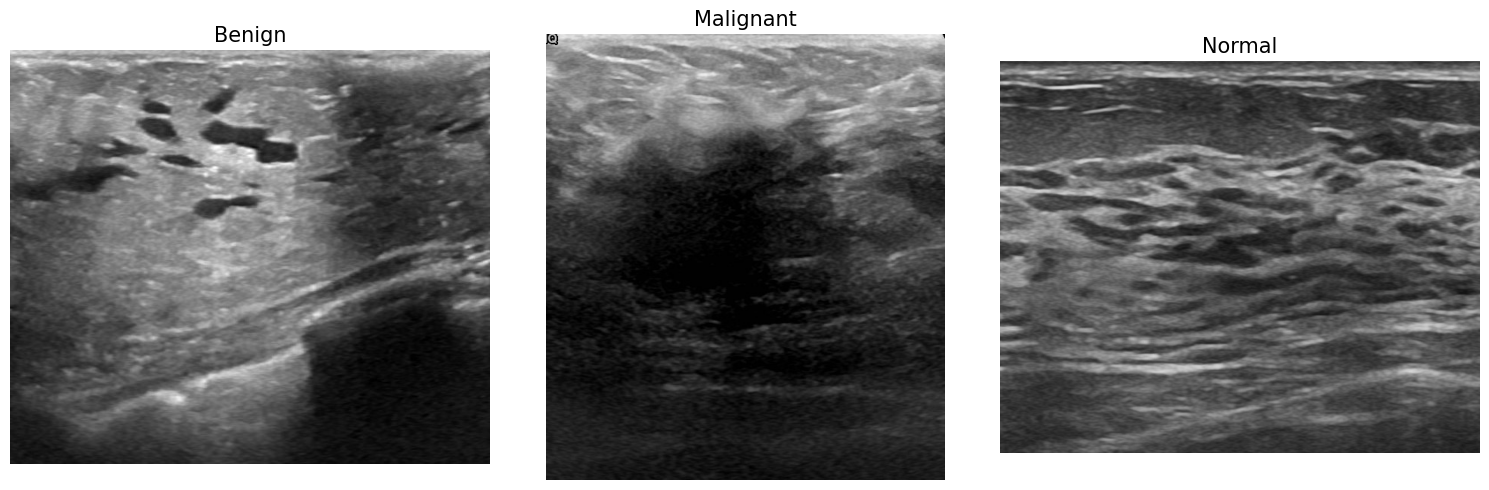

In [69]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(15,5))

for i,cls in enumerate(CLASSES):

    folder=os.path.join(DESTINATION,cls)

    img=random.choice(os.listdir(folder))

    image=Image.open(os.path.join(folder,img))

    plt.subplot(1,3,i+1)

    plt.imshow(image,cmap="gray")

    plt.title(cls.capitalize(),fontsize=15)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [70]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    DESTINATION,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DESTINATION,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:", class_names)

Found 780 files belonging to 3 classes.
Using 624 files for training.
Found 780 files belonging to 3 classes.
Using 156 files for validation.
Classes: ['benign', 'malignant', 'normal']


In [71]:
train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)

print("✅ Dataset Pipeline Ready")

✅ Dataset Pipeline Ready


In [72]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.10),
    RandomZoom(0.15),
    RandomContrast(0.10)
])

print("✅ Data Augmentation Ready")

✅ Data Augmentation Ready


In [73]:
from sklearn.utils.class_weight import compute_class_weight

labels = []

for _, y in train_ds:
    labels.extend(y.numpy())

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: 0.5909090909090909, 1: 1.2530120481927711, 2: 1.9622641509433962}


In [74]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import (
    Input,
    Lambda,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dense,
    Dropout
)

from tensorflow.keras.models import Sequential

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

transfer_model = Sequential([

    Input(shape=(224,224,3)),

    data_augmentation,

    Lambda(preprocess_input),

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dense(256, activation="relu"),

    Dropout(0.5),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(3, activation="softmax")

])

transfer_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [75]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("✅ Model Compiled")

✅ Model Compiled


In [76]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

csv_logger = CSVLogger("training_log.csv")

print("✅ Callbacks Ready")


✅ Callbacks Ready


In [78]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model Compiled Successfully")

✅ Model Compiled Successfully


In [79]:
history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr,
        csv_logger
    ]
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.4832 - loss: 1.3484
Epoch 1: val_accuracy improved from -inf to 0.19872, saving model to best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 849ms/step - accuracy: 0.4867 - loss: 1.3412 - val_accuracy: 0.1987 - val_loss: 1.7299 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.6470 - loss: 0.9010
Epoch 2: val_accuracy improved from 0.19872 to 0.46795, saving model to best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 817ms/step - accuracy: 0.6468 - loss: 0.9019 - val_accuracy: 0.4679 - val_loss: 1.0214 - learning_rate: 0.0010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.6706 - loss: 0.7507
Epoch 3: val_accuracy improved from 0.46795 to 0.82692, saving model to best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 802ms/step - accuracy: 0.6708 - loss: 0.7487 - val_accuracy: 0.8269 - val_loss: 0.5637 - learning_rate: 0.0010
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step 

In [81]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Fine-tuning enabled.")

Fine-tuning enabled.


In [83]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import tensorflow as tf

model = tf.keras.models.load_model(
    "best_model.keras",
    custom_objects={
        "preprocess_input": preprocess_input
    },
    compile=False
)

In [85]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [86]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Accuracy: {accuracy*100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 528ms/step - accuracy: 0.9533 - loss: 0.2326
Validation Accuracy: 96.79%


In [87]:
from google.colab import files
from PIL import Image
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")
image = image.resize((224,224))

image = np.array(image).astype("float32")
image = preprocess_input(image)
image = np.expand_dims(image, axis=0)

prediction = model.predict(image, verbose=0)

print("Raw Prediction:", prediction)

class_names = ["benign", "malignant", "normal"]

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction :", predicted_class)
print("Confidence :", round(confidence,2), "%")

Saving malignant.png to malignant.png
Raw Prediction: [[0.07861418 0.3351927  0.5861931 ]]
Prediction : normal
Confidence : 58.62 %


In [90]:
print(model.summary())

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

None


In [91]:
from google.colab import files
from PIL import Image
import numpy as np

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")
image = image.resize((224, 224))

# IMPORTANT: Do NOT call preprocess_input()
image = np.array(image, dtype=np.float32)
image = np.expand_dims(image, axis=0)

prediction = model.predict(image, verbose=0)

print("Raw Prediction:", prediction)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence:.2f}%")

Saving malignant.png to malignant (1).png
Raw Prediction: [[0.16103294 0.7573575  0.08160959]]
Prediction : malignant
Confidence : 75.74%


In [93]:
import os

SAVE_DIR = "/content/final_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# Native Keras format
model.save(os.path.join(SAVE_DIR, "breast_cancer_model.keras"))

# Weights backup
model.save_weights(
    os.path.join(SAVE_DIR, "breast_cancer_model.weights.h5")
)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [94]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

loaded_model = tf.keras.models.load_model(
    "/content/final_model/breast_cancer_model.keras",
    custom_objects={
        "preprocess_input": preprocess_input
    },
    compile=False
)

print("✅ Model verified successfully!")

✅ Model verified successfully!


In [95]:
from google.colab import files
import shutil

shutil.make_archive(
    "/content/BreastCancerAI_Model",
    "zip",
    "/content/final_model"
)

files.download("/content/BreastCancerAI_Model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [97]:
loss, accuracy = model.evaluate(val_ds, verbose=1)

print("="*60)
print("MODEL EVALUATION")
print("="*60)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 575ms/step - accuracy: 0.9533 - loss: 0.2326
MODEL EVALUATION
Validation Loss     : 0.1769
Validation Accuracy : 96.79%


In [98]:
import numpy as np

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:

    pred = model.predict(images, verbose=0)

    y_prob.extend(pred)

    y_pred.extend(np.argmax(pred, axis=1))

    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

In [100]:
import numpy as np

print("Unique True Labels:", np.unique(y_true))
print("Unique Predicted Labels:", np.unique(y_pred))

print("Class Names:", class_names)

Unique True Labels: [1 2]
Unique Predicted Labels: [1 2]
Class Names: ['benign', 'malignant', 'normal']


In [101]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0,1,2],
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      benign     0.0000    0.0000    0.0000         0
   malignant     0.8750    0.9130    0.8936        23
      normal     0.9848    0.9774    0.9811       133

    accuracy                         0.9679       156
   macro avg     0.6199    0.6302    0.6249       156
weighted avg     0.9687    0.9679    0.9682       156



In [102]:
import numpy as np

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:

    preds = model.predict(images, verbose=0)

    y_prob.extend(preds)

    y_pred.extend(np.argmax(preds, axis=1))

    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Total Validation Images :", len(y_true))
print("Unique Labels :", np.unique(y_true))
print("Unique Predictions :", np.unique(y_pred))

Total Validation Images : 156
Unique Labels : [1 2]
Unique Predictions : [1 2]
